In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# setting ap visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print('Setup Complete')

Setup Complete


# Load Dataset

In [2]:
df = pd.read_csv('/content/retail_sales.csv')
df.head()

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,NaN?,828.585950,12.0,88.591355,East


# Dataset Dimensions, Column names, and Data types

In [3]:
# checking basic info about the dataset
print("---- Dataset Info ---")
print(f"Dataset Dimensions: {df.shape[0]} rows x { df.shape[1]} columns")
print("\nColumn Names and Data types:")
print(df.dtypes)


---- Dataset Info ---
Dataset Dimensions: 1825 rows x 6 columns

Column Names and Data types:
Date         object
Category     object
Sales       float64
Quantity    float64
Profit      float64
Region       object
dtype: object


# Missing Values check and info()

In [4]:
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDataset Summary:")
df.info()


Missing Values:
Date        0
Category    4
Sales       2
Quantity    5
Profit      0
Region      5
dtype: int64

Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   object 
 1   Category  1821 non-null   object 
 2   Sales     1823 non-null   float64
 3   Quantity  1820 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1820 non-null   object 
dtypes: float64(3), object(3)
memory usage: 85.7+ KB


# Data type conversion and cleaning

In [5]:
# converting date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# extracting additional time features
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.day_name()
df['MonthName'] = df['Date'].dt.month_name()

# ensuring numeric columns are properly formatted
numeric_cols = ['Sales', 'Quantity', 'Profit']
for col in numeric_cols:
  df[col] = pd.to_numeric(df[col], errors='coerce')


print('Data types after conversion:')
print(df.dtypes)
print(f"\nData range: {df['Date'].min()} to {df['Date'].max()}")

Data types after conversion:
Date         datetime64[ns]
Category             object
Sales               float64
Quantity            float64
Profit              float64
Region               object
Month                 int32
Quarter               int32
DayOfWeek            object
MonthName            object
dtype: object

Data range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


In [6]:
df_cleaned = df.dropna()
print(df_cleaned.isnull().sum())

Date         0
Category     0
Sales        0
Quantity     0
Profit       0
Region       0
Month        0
Quarter      0
DayOfWeek    0
MonthName    0
dtype: int64


# Statistical Summaries: dispersion, and aggregations by category and region

In [7]:
print("----Statistical Summaries---")
print("Descriptive Statistics for Numerical columns:")
print(df_cleaned[['Sales', 'Quantity', 'Profit']].describe())

----Statistical Summaries---
Descriptive Statistics for Numerical columns:
             Sales     Quantity       Profit
count  1810.000000  1810.000000  1810.000000
mean    980.545247    10.058564   248.386683
std     335.430563     5.511824   117.878805
min       0.000000     0.000000     0.000000
25%     783.973448     5.000000   156.889941
50%     996.222560    10.000000   229.077755
75%    1208.031613    15.000000   323.389568
max    1888.932537    19.000000   703.228418


In [8]:
print("\nCategory-wise Summary:")
category_summary = df.groupby('Category').agg({
    'Sales': ['count', 'sum', 'mean', 'std'],
    'Quantity': ['sum', 'mean'],
    'Profit': ['sum', 'mean']
}).round(2)
print(category_summary)


Category-wise Summary:
            Sales                             Quantity           Profit  \
            count        sum     mean     std      sum   mean       sum   
Category                                                                  
Books         364  370971.87  1019.15  336.39   3737.0  10.27  92304.45   
Clothing      365  350981.82   961.59  337.49   3641.0   9.98  90082.12   
Electronics   360  364090.41  1011.36  344.25   3595.0   9.96  90439.70   
Home Goods    364  347493.83   954.65  332.39   3777.0  10.38  87447.82   
NaN?            1     828.59   828.59     NaN     12.0  12.00     88.59   
Nan             1     823.19   823.19     NaN      4.0   4.00    253.43   
Null            1    1106.85  1106.85     NaN     11.0  11.00    381.78   
Sports        363  346685.06   955.06  331.20   3492.0   9.73  92065.22   

                     
               mean  
Category             
Books        253.58  
Clothing     246.80  
Electronics  250.53  
Home Goods   240.2

In [9]:
print("\nRegion-wise Summary:")
region_summary = df.groupby('Region').agg({
    'Sales': ['sum', 'mean'],
    'Profit': ['sum', 'mean']
}).round(2)
print(region_summary)


Region-wise Summary:
            Sales              Profit        
              sum     mean        sum    mean
Region                                       
East    393441.61   991.04   98973.62  248.68
Nan       1716.71  1716.71     545.62  545.62
North   448295.03   976.68  112126.47  243.75
South   469471.28   969.98  118036.97  243.88
West    470514.37   986.40  122517.78  256.85


# Analyze monthly sales trends + sales and profit pattern throughout the year

In [10]:
# monthly sales trend analysis
print("----Monthly Sales Trend Analysis (Cleaned Data)---")
monthly_sales = df_cleaned.groupby(['Month', 'MonthName']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

monthly_sales = monthly_sales.sort_values(by='Month')
print(monthly_sales)

----Monthly Sales Trend Analysis (Cleaned Data)---
    Month  MonthName          Sales        Profit  Quantity
0       1    January  134435.595627  35420.894813    1394.0
1       2   February  132215.411776  34353.123612    1517.0
2       3      March  145321.200626  38584.599285    1447.0
3       4      April  138160.991209  37895.203187    1446.0
4       5        May  150774.977103  40527.689566    1603.0
5       6       June  152605.749860  39042.686605    1570.0
6       7       July  162111.115687  40208.956109    1536.0
7       8     August  148020.452251  34675.627875    1489.0
8       9  September  153094.700793  37796.761379    1598.0
9      10    October  151272.280840  36019.384158    1569.0
10     11   November  146795.613628  36344.048332    1461.0
11     12   December  159978.807192  38710.920857    1576.0


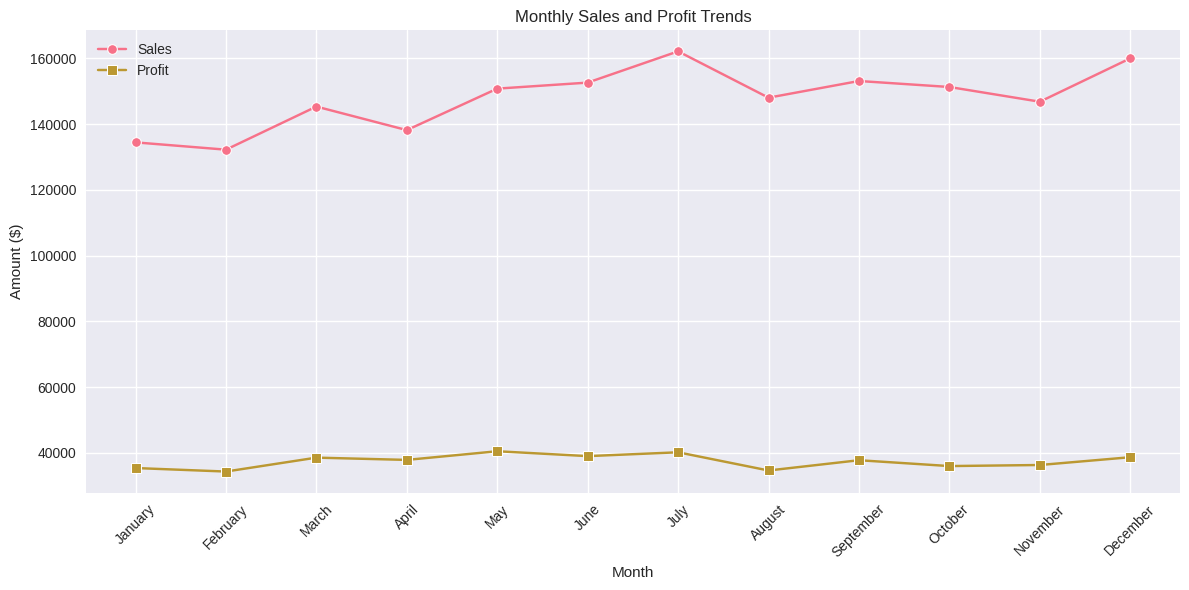

In [11]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='MonthName', y='Sales', marker='o', label='Sales')
sns.lineplot(data=monthly_sales, x='MonthName', y='Profit', marker='s', label='Profit')

plt.title('Monthly Sales and Profit Trends')
plt.xlabel('Month')
plt.ylabel('Amount ($)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Analyze performance product categories

In [12]:
from pandas.core.indexes import category
print("----Product Category Performance Analysis---")

category_performance = df_cleaned.groupby('Category').agg({
    'Sales': 'sum',
    'Quantity': 'sum',
    'Profit': 'sum'
}).sort_values('Sales', ascending=False)
print(category_performance)

----Product Category Performance Analysis---
                     Sales  Quantity        Profit
Category                                          
Books        370971.872558    3737.0  92304.452141
Electronics  364090.406288    3576.0  90181.477134
Clothing     350981.822773    3641.0  90082.119920
Home Goods   344634.290152    3755.0  86993.108551
Sports       341349.880348    3470.0  89294.928796
Null           1106.847949      11.0    381.784578
NaN?            828.585950      12.0     88.591355
Nan             823.190573       4.0    253.433301


In [13]:
# removing Null, NaN?, Nan
df_fully_cleaned = df_cleaned[~df_cleaned['Category'].isin(['Null', 'NaN?', 'Nan'])]

print("----Product Category Performance Analysis---")
category_performance = df_fully_cleaned.groupby('Category').agg({
    'Sales': 'sum',
    'Quantity': 'sum',
    'Profit': 'sum'
}).sort_values('Sales', ascending=False)

display(category_performance)

----Product Category Performance Analysis---


,Sales,Quantity,Profit
Category,,,
Books,370971.872558,3737.0,92304.452141
Electronics,364090.406288,3576.0,90181.477134
Clothing,350981.822773,3641.0,90082.119920
Home Goods,344634.290152,3755.0,86993.108551
Sports,341349.880348,3470.0,89294.928796


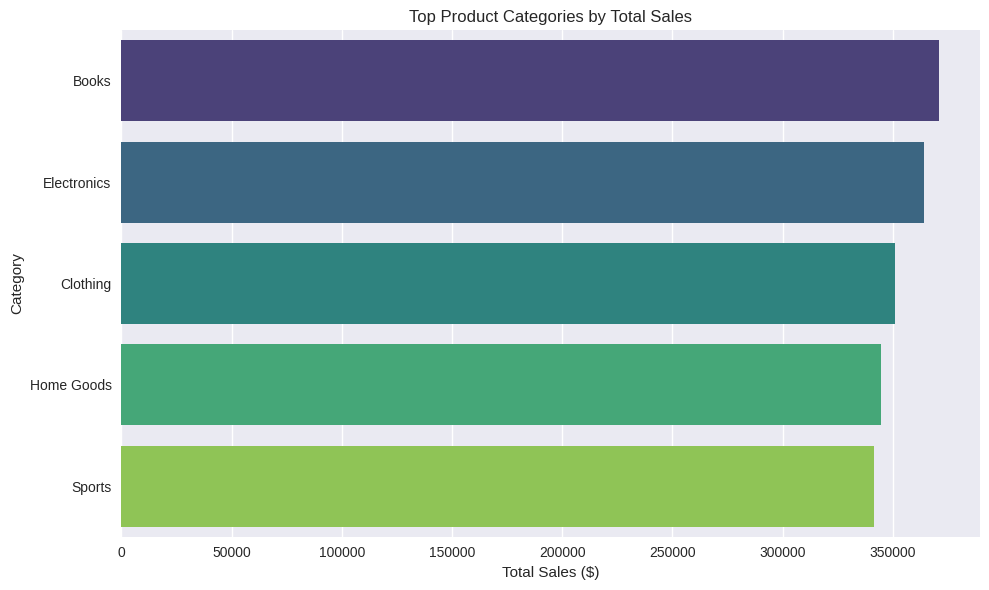

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(data=category_performance, x='Sales', y='Category', palette='viridis')
plt.title('Top Product Categories by Total Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Category')
plt.tight_layout()

In [15]:
# removing Nan from regions
df_fully_cleaned = df_fully_cleaned[~df_fully_cleaned['Region'].isin(['Nan', 'NaN?', 'Null'])]

print("---- Regional Performance Analysis ----")

region_performance = df_fully_cleaned.groupby('Region').agg({
    'Sales': 'sum',
    'Quantity': 'sum',
    'Profit': 'sum'
}).sort_values('Sales', ascending=False)

display(region_performance)

---- Regional Performance Analysis ----


,Sales,Quantity,Profit
Region,,,
West,468345.826839,4657.0,121947.664564
South,466191.598822,4781.0,117316.008728
North,445618.542850,4674.0,110775.161869
East,390155.592821,4059.0,98271.633655


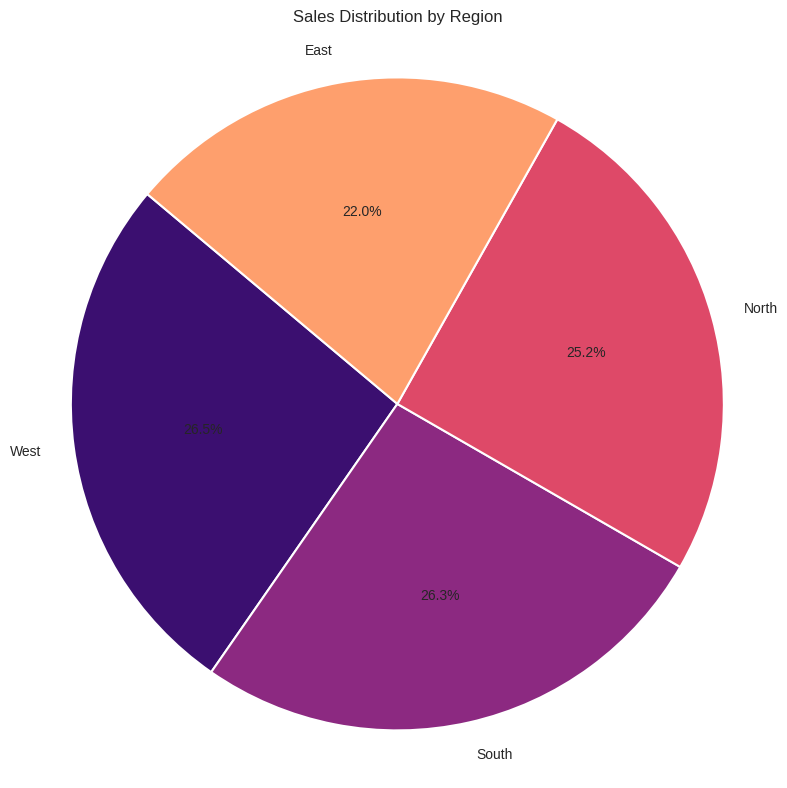

In [16]:
plt.figure(figsize=(8, 8))
plt.pie(
    region_performance['Sales'],
    labels=region_performance.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('magma', len(region_performance)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Sales Distribution by Region')
plt.axis('equal')
plt.tight_layout()

# Correlation and analysis

---- Correlation Analysis ----
             Sales  Quantity    Profit
Sales     1.000000  0.055664  0.530954
Quantity  0.055664  1.000000  0.030709
Profit    0.530954  0.030709  1.000000


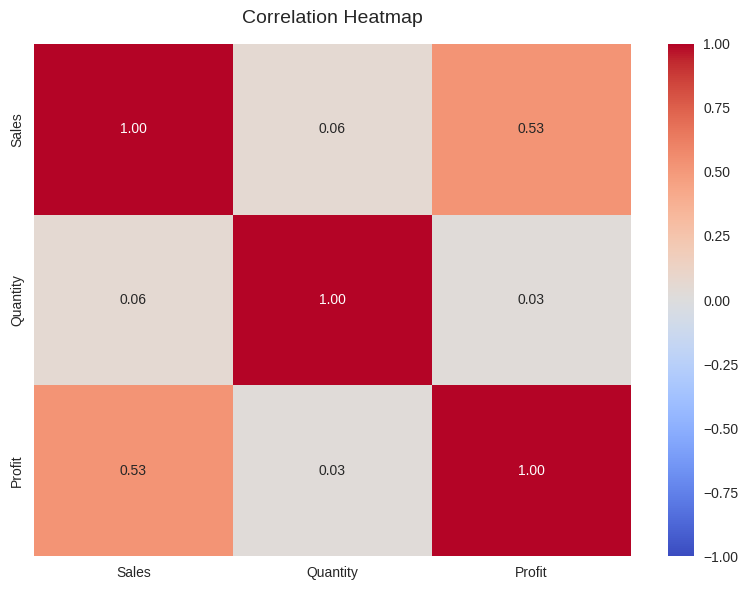

In [18]:
print("---- Correlation Analysis ----")

numeric_cols = ['Sales', 'Quantity', 'Profit']
corr_matrix = df_fully_cleaned[numeric_cols].corr()

print(corr_matrix)

# heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    fmt='.2f'
)
plt.title('Correlation Heatmap', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Final Summary Dashboard

---- Executive Summary Dashboard ----


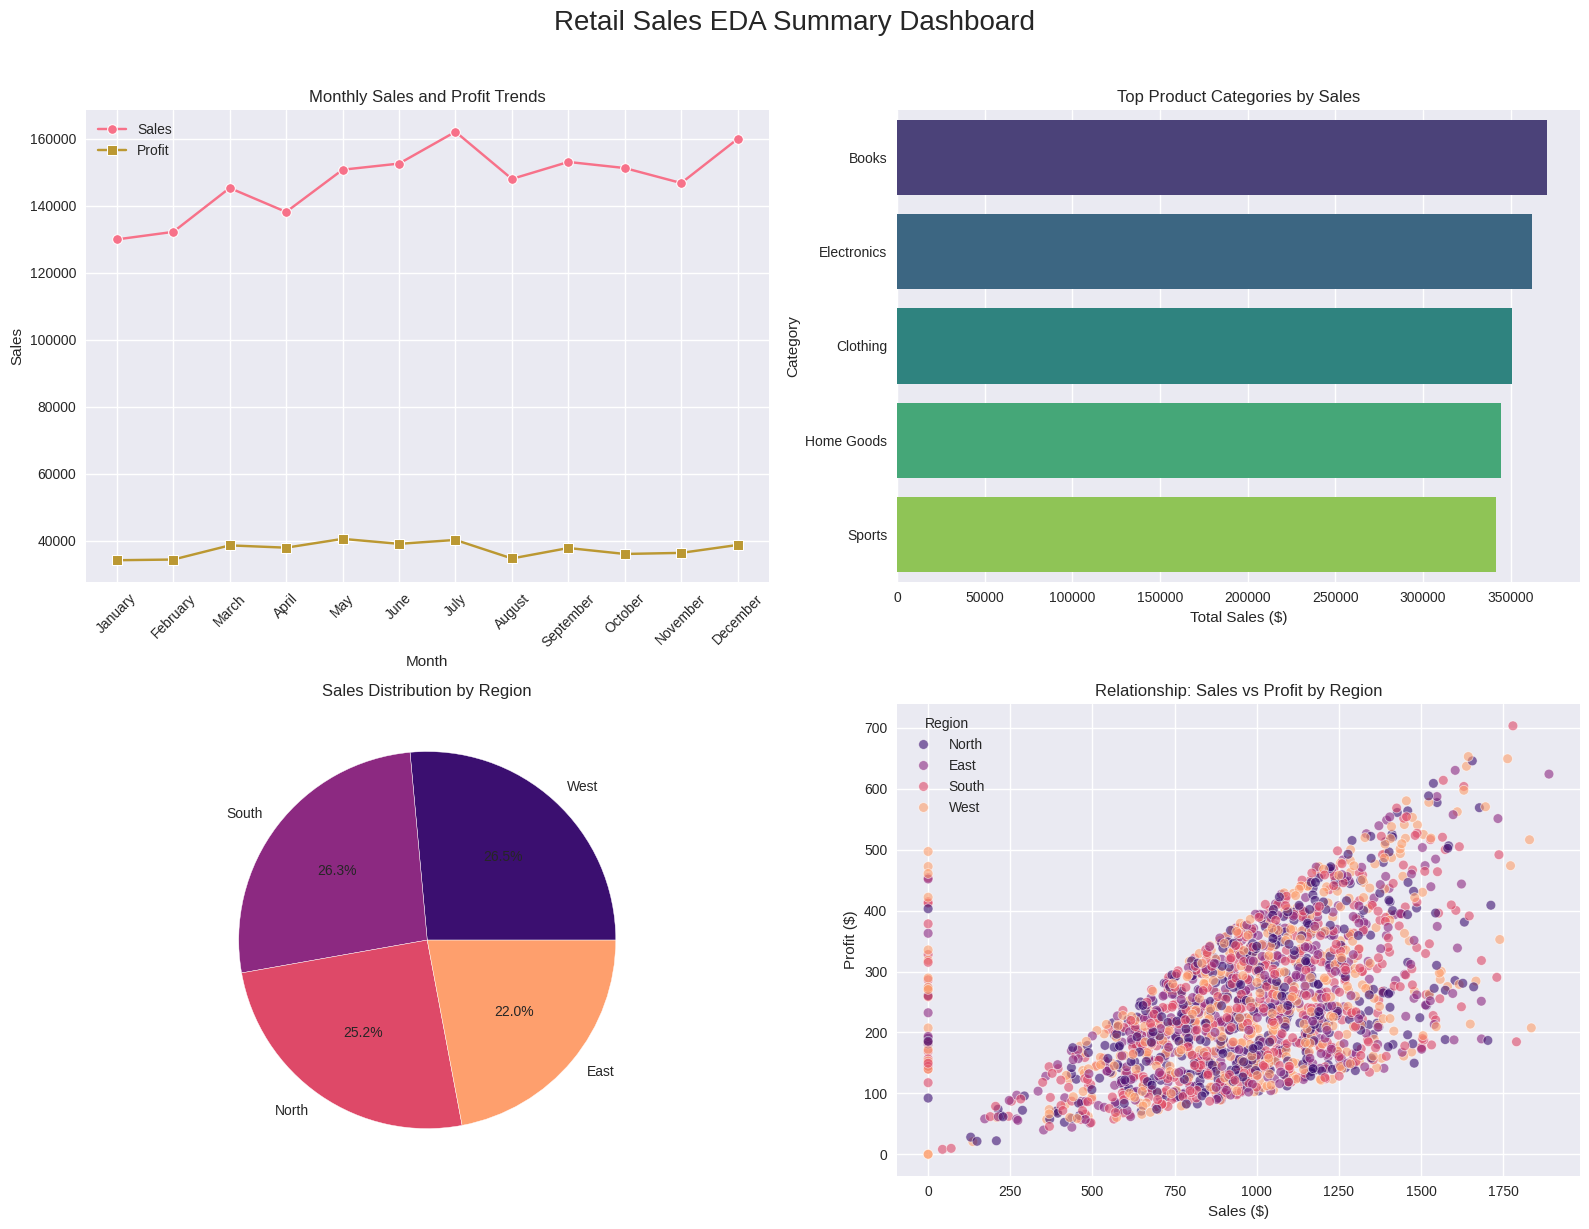

In [19]:
print("---- Executive Summary Dashboard ----")

# 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Retail Sales EDA Summary Dashboard', fontsize=20, y=1.02)

# Top-Left: Monthly Trends
monthly_sales = df_fully_cleaned.groupby(['Month', 'MonthName']).agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index().sort_values('Month')
sns.lineplot(data=monthly_sales, x='MonthName', y='Sales', marker='o', label='Sales', ax=axes[0, 0])
sns.lineplot(data=monthly_sales, x='MonthName', y='Profit', marker='s', label='Profit', ax=axes[0, 0])
axes[0, 0].set_title('Monthly Sales and Profit Trends', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_xlabel('Month')

# Top-Right: Category Performance
cat_perf = df_fully_cleaned.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=cat_perf, x='Sales', y='Category', palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Top Product Categories by Sales', fontsize=12)
axes[0, 1].set_xlabel('Total Sales ($)')

# Bottom-Left: Region Distribution
reg_perf = df_fully_cleaned.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[1, 0].pie(reg_perf, labels=reg_perf.index, autopct='%1.1f%%', colors=sns.color_palette('magma', len(reg_perf)), wedgeprops={'edgecolor': 'white'})
axes[1, 0].set_title('Sales Distribution by Region', fontsize=12)

# Bottom-Right: Sales vs Profit Scatter
sns.scatterplot(data=df_fully_cleaned, x='Sales', y='Profit', hue='Region', palette='magma', alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title('Relationship: Sales vs Profit by Region', fontsize=12)
axes[1, 1].set_xlabel('Sales ($)')
axes[1, 1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.show()